In [1]:
import rospy
import actionlib
from IPython.display import display, clear_output
import ipywidgets as widgets
from nav_msgs.msg import Odometry
from sensor_msgs.msg import LaserScan
from assignment_2_2024.msg import PlanningAction, PlanningGoal, robot_par
from actionlib import GoalStatus
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from threading import Lock
import ipywidgets as widgets

%matplotlib notebook

In [2]:
# Global variables
client = None
pub_pos_vel = None
goal_active = False

# Robot tracking
robot_path = []
path_lock = Lock()
reached_targets = 0
unreached_targets = 0

In [3]:
# ROS Node Init
rospy.init_node('set_target_notebook', anonymous=True)

# Publisher
pub_pos_vel = rospy.Publisher('/robot_position_velocity', robot_par, queue_size=10)
client = actionlib.SimpleActionClient('/reaching_goal', PlanningAction)
client.wait_for_server()

True

In [4]:
# Input per X e Y
x_input = widgets.FloatText(description='X:', layout=widgets.Layout(width='50%'))
y_input = widgets.FloatText(description='Y:', layout=widgets.Layout(width='50%'))

# Pulsanti
set_button = widgets.Button(description="Set Goal", button_style='success', layout=widgets.Layout(width='50%'))
cancel_button = widgets.Button(description="Cancel Goal", button_style='danger', layout=widgets.Layout(width='50%'))

#
robot_position_label = widgets.Label(value="Position: (x: ---, y: ---)")
closest_obstacle_label = widgets.Label(value="Closest Obstacle: --- m")

output = widgets.Output()


In [5]:
# Callbacks
def feedback_cb(feedback):
    if feedback.stat == "Target reached!":
        with output:
            print(f"\nTarget reached at ({feedback.actual_pose.position.x}, {feedback.actual_pose.position.y})")

def done_cb(status, result):
    global reached_targets, unreached_targets
    with output:
        if status == GoalStatus.SUCCEEDED:
            reached_targets += 1
            print("Goal reached.")
        else:
            unreached_targets += 1
            print("Goal not reached.")

def odom_callback(msg):
    x = msg.pose.pose.position.x
    y = msg.pose.pose.position.y
    vel_x = msg.twist.twist.linear.x
    vel_z = msg.twist.twist.angular.z
    
    robot_param = robot_par()
    robot_param.x = x
    robot_param.y = y
    robot_param.vel_x = vel_x
    robot_param.vel_z = vel_z
    pub_pos_vel.publish(robot_param)

    robot_position_label.value = f"Position: (x: {x:.2f}, y: {y:.2f})"

def scan_callback(msg):
    if msg.ranges:
        min_distance = np.nanmin(msg.ranges)
        closest_obstacle_label.value = f"Closest Obstacle: {min_distance:.2f} m"

def position_callback(msg):
    with path_lock:
        robot_path.append((msg.x, msg.y))

In [6]:
# Button bindings
def send_goal(_):
    global goal_active
    goal = PlanningGoal()
    goal.target_pose.pose.position.x = x_input.value
    goal.target_pose.pose.position.y = y_input.value
    client.send_goal(goal, done_cb=done_cb, feedback_cb=feedback_cb)
    goal_active = True
    with output:
        clear_output()
        print(f"Goal sent to: ({x_input.value}, {y_input.value})")

def cancel_goal(_):
    global goal_active
    if client.get_state() in [GoalStatus.ACTIVE, GoalStatus.PENDING]:
        client.cancel_goal()
        rospy.sleep(0.5)
        state = client.get_state()
        with output:
            clear_output()
            if state in [GoalStatus.PREEMPTED, GoalStatus.RECALLED]:
                print("Goal successfully cancelled.")
                goal_active = False
            else:
                print("Failed to cancel goal.")
    else:
        with output:
            clear_output()
            print("No active goal to cancel.")

set_button.on_click(send_goal)
cancel_button.on_click(cancel_goal)

In [7]:
# ROS subscribers
rospy.Subscriber('/odom', Odometry, odom_callback)
rospy.Subscriber('/scan', LaserScan, scan_callback)
rospy.Subscriber('/robot_position_velocity', robot_par, position_callback)

In [8]:
# Display UI
display(widgets.VBox([
    widgets.HBox([x_input, y_input]),
    widgets.HBox([set_button, cancel_button]),
    robot_position_label,
    closest_obstacle_label,
    output
]))

<IPython.core.display.Javascript object>


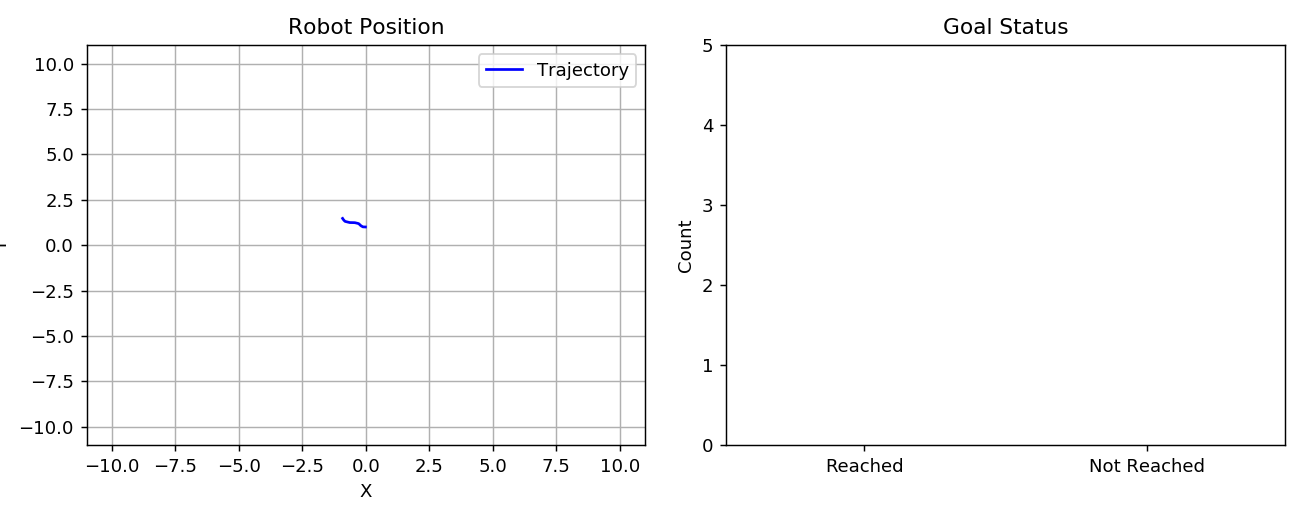

In [10]:
# Live Plot
fig, (ax_traj, ax_stats) = plt.subplots(1, 2, figsize=(10, 4))
trajectory_line, = ax_traj.plot([], [], 'b-', label='Trajectory')
ax_traj.set_title("Robot Position")
ax_traj.set_xlabel("X")
ax_traj.set_ylabel("Y")
ax_traj.legend()
ax_traj.grid(True)

bars = ax_stats.bar(["Reached", "Not Reached"], [0, 0], color=["green", "red"])
ax_stats.set_ylim(0, 10)
ax_stats.set_title("Goal Status")
ax_stats.set_ylabel("Count")

def update(frame):
    with path_lock:
        if robot_path:
            xs, ys = zip(*robot_path)
            trajectory_line.set_data(xs, ys)
            ax_traj.set_xlim([-11, 11])
            ax_traj.set_ylim([-11, 11])
            

    bars[0].set_height(reached_targets)
    bars[1].set_height(unreached_targets)
    ax_stats.set_ylim(0, max(5, reached_targets + unreached_targets + 1))
    return trajectory_line, bars

ani = FuncAnimation(fig, update, interval=1000)
plt.tight_layout()